In [185]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


# Load Data

- parse date
- create MonthNum column so we can do a regression later

In [186]:
df = pd.read_excel("Analyst_case_study_dataset_1.xls")
df_backup = df.copy()
df["LeadCreated"] = pd.to_datetime(df["LeadCreated"])
df["YearMonth"] = df["LeadCreated"].dt.strftime("%Y-%m")
df["MonthNum"] = (df["LeadCreated"].dt.year - 2009) * 12 + df["LeadCreated"].dt.month - 4

# Define Quality categories
- Good: 

In [187]:
GOOD=["Closed", "EP Sent", "EP Received", "EP Confirmed"]
BAD=["Unable to contact - Bad Contact Information",
        "Contacted - Doesn't Qualify",
        "Contacted - Invalid Profile"
        ]
df["IsGood"]= df["CallStatus"].isin(GOOD).astype(int)
df["IsBad"] = df["CallStatus"].isin(BAD).astype(int)
df["HasStatus"] = (df["IsGood"] | df["IsBad"])
overall = df["IsGood"].sum() / len(df)
print(f"Overall quality rate: {overall:.2%} (baseline for comparison)")

Overall quality rate: 13.01% (baseline for comparison)


# Overall Stats

In [188]:
print(df["CallStatus"].value_counts(dropna=False))
print(f"\nTotal leads  : {len(df)}")
print(f"Good leads   : {df['IsGood'].sum()}")
print(f"Bad leads    : {df['IsBad'].sum()}")
print(f"Unknown      : {(df['HasStatus'] == 0).sum()}")
print(f"\nQuality Rate (Good / Total)     : {df['IsGood'].mean():.1%}")
print(f"Quality Rate (Good / Good+Bad)  : {df['IsGood'].sum() / df['HasStatus'].sum():.1%}")


CallStatus
NaN                                            2140
Closed                                          245
Contacted - Doesn't Qualify                     212
Unable to contact - Bad Contact Information     191
EP Confirmed                                    130
Contacted - Invalid Profile                      85
EP Sent                                          16
EP Received                                       2
Name: count, dtype: int64

Total leads  : 3021
Good leads   : 393
Bad leads    : 488
Unknown      : 2140

Quality Rate (Good / Total)     : 13.0%
Quality Rate (Good / Good+Bad)  : 44.6%


# Monthly trend

In [189]:
monthly = (
    df.groupby("YearMonth")
    .agg(Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum"))
    .reset_index()
)
monthly["QualityRate"] = monthly["Good"] / monthly["Total"]
# print(monthly.to_string(index=False))

# Linear regression to test for trend
monthly_num = df.groupby("MonthNum").agg(
    Good=("IsGood", "sum"), Total=("VendorLeadID", "count")
).reset_index()
monthly_num["Rate"] = monthly_num["Good"] / monthly_num["Total"]
print(monthly_num.to_string(index=False))
x = monthly_num["MonthNum"].values
y = monthly_num["Rate"].values
slope, intercept, r, p, se = stats.linregress(x, y)
r_squared = r ** 2
trend_y = intercept + slope * x
print(f"\nLinear trend: slope={slope:.4f}/month, p={p:.4f}, R^2={r_squared:.4f}, se={se:.4f},intercept={intercept:.4f}")
print(f"Result: {'SIGNIFICANT' if p < 0.05 else 'NOT statistically significant'} at α=0.05")


 MonthNum  Good  Total     Rate
        0    79    517 0.152805
        1    59    579 0.101900
        2    86    606 0.141914
        3    49    531 0.092279
        4    62    436 0.142202
        5    58    344 0.168605

Linear trend: slope=0.0043/month, p=0.6059, R^2=0.0725, se=0.0077,intercept=0.1226
Result: NOT statistically significant at α=0.05


## visualization of monthly trend
- added a target line from Q3

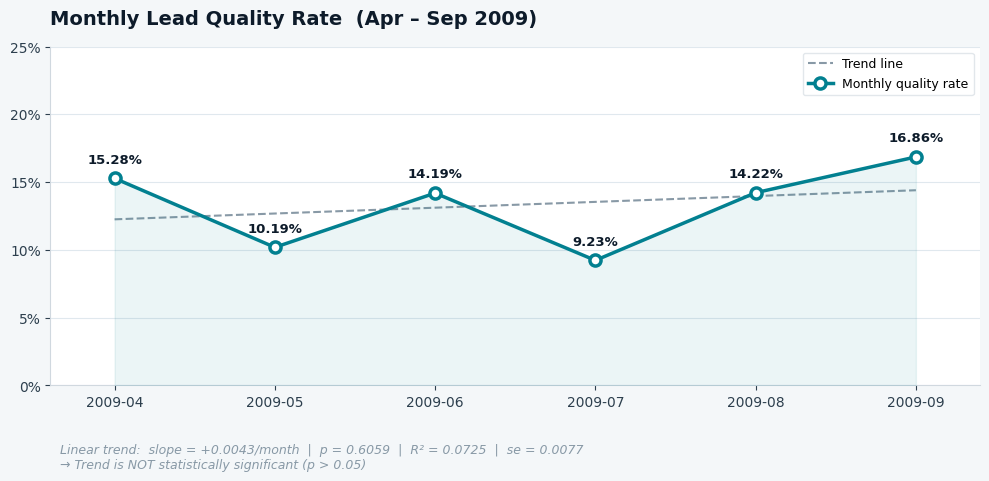

In [190]:
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor("#F4F7F9")
ax.set_facecolor("#FFFFFF")

#       trend line
ax.plot(x, trend_y, color="#8899A6", linewidth=1.5,
        linestyle="--", zorder=2, label="Trend line")
# actual data points
ax.plot(x, y, color="#028090", linewidth=2.5,
        marker="o", markersize=8, markerfacecolor="white",
        markeredgewidth=2.5, zorder=4, label="Monthly quality rate")
# labels
for xi, yi in zip(x, y):
    ax.text(xi, yi + 0.009, f"{yi:.2%}",
            ha="center", va="bottom", fontsize=9.5,
            color="#0D1B2A", fontweight="bold")

# shaded area under the curve
ax.fill_between(x, y, alpha=0.08, color="#028090", zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(monthly["YearMonth"], fontsize=10)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.25)
ax.set_xlim(-0.4, len(x) - 0.6)
ax.tick_params(axis="both", labelsize=10, colors="#2D3F4E")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D0D8DF")
ax.yaxis.grid(True, color="#E0E8EE", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title("Monthly Lead Quality Rate  (Apr – Sep 2009)",
             fontsize=14, fontweight="bold", color="#0D1B2A",
             pad=16, loc="left")

stats_text = (
    f"Linear trend:  slope = {slope:+.4f}/month  |  "
    f"p = {p:.4f}  |  R² = {r_squared:.4f}  |  se = {se:.4f}\n"
    f"→ Trend is NOT statistically significant (p > 0.05)"
)
ax.text(0.01, -0.17, stats_text,
        transform=ax.transAxes,
        fontsize=9, color="#8899A6", style="italic",
        verticalalignment="top")

ax.legend(loc="upper right", fontsize=9, framealpha=0.6,
          edgecolor="#D0D8DF")

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("monthly_quality_trend.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# Drivers
- widgets
- PublisherZoneName
- PublisherCampaignName
- debt level
- phone & address score
- phone score+debt level
- partner&traffic source
- states
- marketing

## Drivers - widgets

In [191]:
df["WidgetName"] = df["WidgetName"].str.replace("w-302252-","w-300250-", regex=False)
df["WidgetName"].unique()

widget = (
    df.groupby("WidgetName")
    .agg(Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum"))
    .reset_index()
)
widget["QualRate"] = widget["Good"] / widget["Total"]

print(widget.sort_values("QualRate", ascending=False).to_string(index=False))

# 1DC vs 2DC
df["FormPages"] = df["WidgetName"].str.extract(r"-(1DC|2DC)-")
dc = df.groupby("FormPages").agg(
    Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum")
).reset_index()
dc["QualRate"] = dc["Good"] / dc["Total"]
print("\n1DC vs 2DC Form Pages:")
print(dc.to_string(index=False))


# Advertiser campaign (branded vs generic)
adv = df.groupby("AdvertiserCampaignName").agg(
    Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum")
).reset_index()
adv["QualRate"] = adv["Good"] / adv["Total"]
print("\nAdvertiser Campaign (branded vs generic):")
print(adv.to_string(index=False))

                                  WidgetName  Total  Good  Bad  QualRate
     w-300250-DebtReduction1-1DC-yellowarrow     49    12    9  0.244898
           w-300250-DebtReduction1-1DC-Head2     89    14    8  0.157303
       w-300250-DebtReduction1-1DC-BlueMeter     92    14    4  0.152174
                 w-300250-DebtReduction1-1DC    619    88  118  0.142165
       w-300250-DebtReduction1-2DC-BlueMeter     87    12    9  0.137931
w-300250-DebtReduction1-1DC-yellowarrow-blue    230    31   49  0.134783
 w-300250-DebtReduction1-1DC-CreditSolutions   1128   149  178  0.132092
w-300250-DebtReduction1-1DC-yellowarrow-dark    135    15   25  0.111111
 w-300250-DebtReduction1-2DC-CreditSolutions     75     8   12  0.106667
           w-300250-DebtReduction1-1DC-white    434    45   69  0.103687
           w-300250-DebtReduction1-1DC-Head3     75     5    7  0.066667

1DC vs 2DC Form Pages:
FormPages  Total  Good  Bad  QualRate
      1DC   2232   285  349  0.127688
      2DC    162    20  

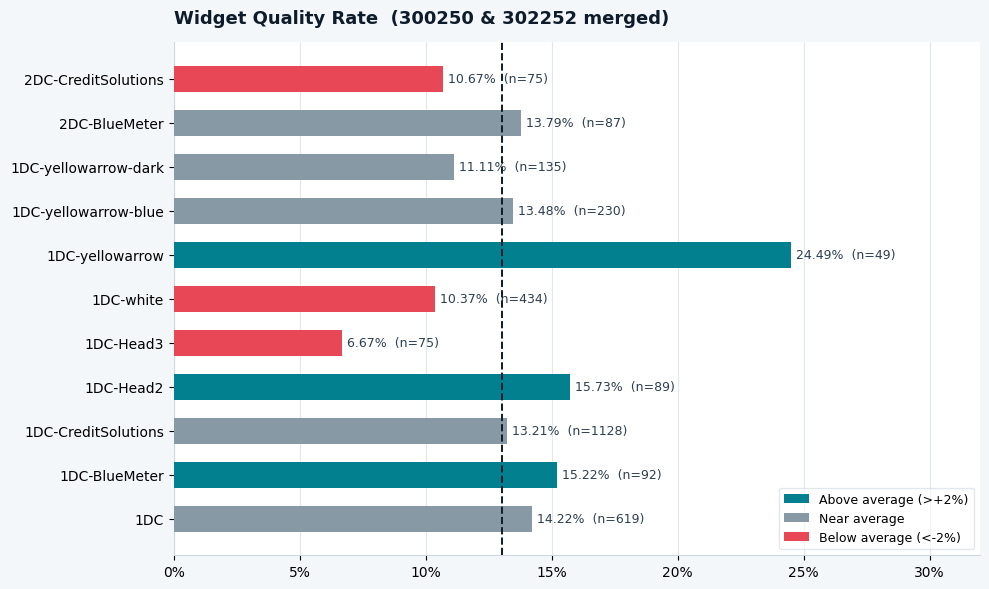

In [192]:
# this is for better display only, not used in analysis
widget["Label"] = (widget["WidgetName"]
                   .str.replace("w-300250-DebtReduction1-", "", regex=False))
colors = []
for r in widget["QualRate"]:
    if r >= overall + 0.02:
        colors.append("#028090")
    elif r <= overall - 0.02:
        colors.append("#E84855")
    else:
        colors.append("#8899A6")

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#F4F7F9")
ax.set_facecolor("#FFFFFF")

bars = ax.barh(widget["Label"], widget["QualRate"], color=colors, height=0.6, zorder=3)

# baseline line
ax.axvline(x=overall, color="#0D1B2A", linewidth=1.4,
           linestyle="--", zorder=4, label=f"Overall avg {overall:.2%}")


for bar, val, total in zip(bars, widget["QualRate"], widget["Total"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.2%}  (n={total})",
            va="center", fontsize=9, color="#2D3F4E")

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, 0.32)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D0D8DF")
ax.xaxis.grid(True, color="#E0E8EE", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(labelsize=10)

ax.set_title("Widget Quality Rate  (300250 & 302252 merged)",
             fontsize=13, fontweight="bold", color="#0D1B2A", pad=14, loc="left")
ax.legend(fontsize=9, framealpha=0.6, edgecolor="#D0D8DF")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#028090", label="Above average (>+2%)"),
    Patch(facecolor="#8899A6", label="Near average"),
    Patch(facecolor="#E84855", label="Below average (<-2%)"),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.6,
          edgecolor="#D0D8DF", loc="lower right")

plt.tight_layout()
plt.savefig("widget_quality.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## Drivers - Publisher Zone & Campaign Type

In [193]:
for col, label in [("PublisherZoneName", "Publisher Zone"), ("PublisherCampaignName", "Campaign Type")]:
    grp = df.groupby(col).agg(
        Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum")
    ).reset_index()
    grp["QualRate"] = grp["Good"] / grp["Total"]
    print(f"\n{label}:")
    print(grp.to_string(index=False))


Publisher Zone:
PublisherZoneName  Total  Good  Bad  QualRate
Top Right-300x250    271    44   66  0.162362
   TopLeft-302252   2742   349  422  0.127279

Campaign Type:
  PublisherCampaignName  Total  Good  Bad  QualRate
DebtReductionCallCenter    271    44   66  0.162362
       DebtReductionInc   2742   349  422  0.127279


## Drivers - debt level

In [194]:
debt_order = ["7500-10000", "7500-15000", "10001-15000", "15001-20000",
              "20001-30000", "30001-50000", "50001-70000",
              "70001-90000", "90000-100000", "More_than_100000"]

debt = (
    df.groupby("DebtLevel")
    .agg(Total=("VendorLeadID","count"), Good=("IsGood","sum"), Bad=("IsBad","sum"))
    .reindex(debt_order).reset_index()
)
debt["QualRate"] = debt["Good"] / debt["Total"]
debt["vs_avg"]   = debt["QualRate"] - overall

print("DEBT LEVEL")
print("=" * 65)
print(debt[["DebtLevel","Total","Good","Bad","QualRate","vs_avg"]].to_string(index=False))


EXCLUDE = ["7500-10000", "More_than_100000"]
ends   = df[df["DebtLevel"].isin(EXCLUDE)]
middle = df[~df["DebtLevel"].isin(EXCLUDE)]

print(f"\nEdge ({', '.join(EXCLUDE)}):")
print(f"  n={len(ends)}, quality={ends['IsGood'].mean():.1%}")
print(f"\nMiddle segment:")
print(f"  n={len(middle)}, quality={middle['IsGood'].mean():.1%}")

ct = [[ends["IsGood"].sum(),   ends["IsBad"].sum()],
      [middle["IsGood"].sum(), middle["IsBad"].sum()]]
chi2_val, p_val, _, _ = chi2_contingency(ct)
print(f"\nChi-squared (Edge vs Middle): chi2={chi2_val:.2f}, p={p_val:.6f}")
print(f"Result: {'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'}")
print(f"\nResult: Edge（7.0%）vs Middle（14.6%），significant（p<0.0001）")
print(f"EXCLUDE_DEBT = ['7500-10000', 'More_than_100000']")


DEBT LEVEL
       DebtLevel  Total  Good  Bad  QualRate    vs_avg
      7500-10000    440    31  109  0.070455 -0.059635
      7500-15000    270    31   26  0.114815 -0.015275
     10001-15000    291    54   49  0.185567  0.055478
     15001-20000    408    57   49  0.139706  0.009617
     20001-30000    454    72   70  0.158590  0.028501
     30001-50000    495    61   84  0.123232 -0.006857
     50001-70000    244    38   34  0.155738  0.025648
     70001-90000    131    25   16  0.190840  0.060750
    90000-100000     90    11   13  0.122222 -0.007867
More_than_100000    190    13   38  0.068421 -0.061668

Edge (7500-10000, More_than_100000):
  n=633, quality=7.0%

Middle segment:
  n=2388, quality=14.6%

Chi-squared (Edge vs Middle): chi2=44.82, p=0.000000
Result: SIGNIFICANT

Result: Edge（7.0%）vs Middle（14.6%），significant（p<0.0001）
EXCLUDE_DEBT = ['7500-10000', 'More_than_100000']


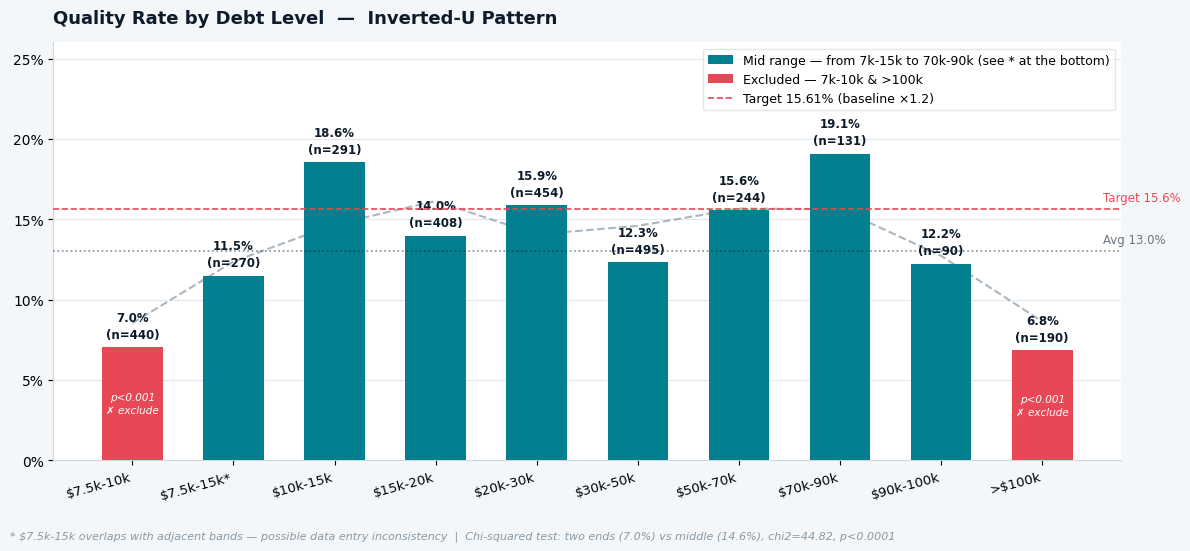

Saved debt_level_distribution.png


In [195]:
labels = ["$7.5k-10k", "$7.5k-15k*", "$10k-15k", "$15k-20k",
          "$20k-30k", "$30k-50k", "$50k-70k",
          "$70k-90k", "$90k-100k", ">$100k"]

# color coding: red for excluded ends, blue for middle segments
EXCLUDE = ["7500-10000", "More_than_100000"]
colors = ["#E84855" if d in EXCLUDE else "#028090" for d in debt["DebtLevel"]]

fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor("#F4F7F9")
ax.set_facecolor("#FFFFFF")

x = np.arange(len(debt))
bars = ax.bar(x, debt["QualRate"], color=colors, width=0.6, zorder=3)

ax.axhline(y=overall, color="#0D1B2A", linewidth=1.2,
           linestyle=":", alpha=0.5, zorder=4)
ax.text(len(x) - 0.4, overall + 0.005,
        f"Avg {overall:.1%}", fontsize=8.5, color="#0D1B2A", alpha=0.6)

target  = overall * 1.2

# target line
ax.axhline(y=target, color="#E84855", linewidth=1.2,
           linestyle="--", zorder=4)
ax.text(len(x) - 0.4, target + 0.005,
        f"Target {target:.1%}", fontsize=8.5, color="#E84855")

# data
for bar, rate, n, d in zip(bars, debt["QualRate"], debt["Total"], debt["DebtLevel"]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            rate + 0.004,
            f"{rate:.1%}\n(n={n})",
            ha="center", va="bottom", fontsize=8.5,
            fontweight="bold", color="#0D1B2A", linespacing=1.4)
    # if significant, add annotation
    if d in EXCLUDE:
        ax.text(bar.get_x() + bar.get_width() / 2,
                rate / 2,
                "p<0.001\n✗ exclude",
                ha="center", va="center", fontsize=7.5,
                color="white", fontstyle="italic", linespacing=1.4)

# smooth line
from scipy.ndimage import uniform_filter1d
smooth = uniform_filter1d(debt["QualRate"].values, size=3)
ax.plot(x, smooth, color="#8899A6", linewidth=1.5,
        linestyle="--", zorder=2, alpha=0.7, label="Smoothed trend")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9.5, rotation=15, ha="right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.26)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D0D8DF")
ax.yaxis.grid(True, color="#E0E8EE", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(facecolor="#028090", label="Mid range — from 7k-15k to 70k-90k (see * at the bottom)"),
    mpatches.Patch(facecolor="#E84855", label="Excluded — 7k-10k & >100k"),
    plt.Line2D([0],[0], color="#E84855", linestyle="--", linewidth=1.2,
               label=f"Target {target:.2%} (baseline ×1.2)"),
]
ax.legend(handles=legend_elements, fontsize=9,
          framealpha=0.6, edgecolor="#D0D8DF", loc="upper right")

ax.set_title("Quality Rate by Debt Level  —  Inverted-U Pattern",
             fontsize=13, fontweight="bold", color="#0D1B2A", pad=14, loc="left")

fig.text(0.01, 0.01,
         "* $7.5k-15k overlaps with adjacent bands — possible data entry inconsistency  |  "
         "Chi-squared test: two ends (7.0%) vs middle (14.6%), chi2=44.82, p<0.0001",
         fontsize=8, color="#8899A6", style="italic")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("debt_level_distribution.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved debt_level_distribution.png")

## Drivers - phone score & address score

In [196]:
phone = df.groupby("PhoneScore").agg(
    Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum")
).reset_index()
phone["QualRate"] = phone["Good"] / phone["Total"]
print(phone.to_string(index=False))

df_ph = df.dropna(subset=["PhoneScore"])
ph5    = df_ph[df_ph["PhoneScore"] == 5]
photh  = df_ph[df_ph["PhoneScore"] != 5]
ct_ph  = [[ph5["IsGood"].sum(), ph5["IsBad"].sum()],
          [photh["IsGood"].sum(), photh["IsBad"].sum()]]
chi2_ph, p_ph, _, _ = chi2_contingency(ct_ph)
print(f"\nChi-squared (Phone Score 5 vs others): chi2={chi2_ph:.2f}, p={p_ph:.6f}")
print(f"Result: {'SIGNIFICANT' if p_ph < 0.05 else 'NOT significant'}")

 PhoneScore  Total  Good  Bad  QualRate
        1.0      1     0    1  0.000000
        2.0    160    16   33  0.100000
        3.0    426    50   86  0.117371
        4.0    184    13   31  0.070652
        5.0    619   100   96  0.161551

Chi-squared (Phone Score 5 vs others): chi2=11.40, p=0.000735
Result: SIGNIFICANT


In [197]:
def score_summary(df, col):
    d = df.dropna(subset=[col]).copy()
    d[col] = d[col].astype(int)
    grp = d.groupby(col).agg(
        Total=("VendorLeadID","count"),
        Good=("IsGood","sum"),
        Bad=("IsBad","sum")
    ).reset_index()
    grp["QualRate"] = grp["Good"] / grp["Total"]
    coverage = len(d) / len(df)
    # Score 5 vs others chi-squared
    s5   = d[d[col] == 5]
    soth = d[d[col] != 5]
    ct = [[s5["IsGood"].sum(),   s5["IsBad"].sum()],
          [soth["IsGood"].sum(), soth["IsBad"].sum()]]
    chi2, p, _, _ = chi2_contingency(ct)
    # All scores chi-squared
    ct_all = [[r["Good"], r["Bad"]] for _, r in grp.iterrows()]
    chi2_all, p_all, _, _ = chi2_contingency(ct_all)
    print(f"=== {col} ===")
    print(grp.to_string(index=False))
    print(f"Coverage: {coverage:.0%}")
    print(f"Score 5 vs others: chi2={chi2:.2f}, p={p:.4f}")
    print(f"All scores:        chi2={chi2_all:.2f}, p={p_all:.4f}")
    print(f"\nChi-squared (Score 5 vs others): chi2={chi2:.2f}, p={p:.6f}")
    print(f"Result: {'SIGNIFICANT' if p < 0.05 else 'NOT significant'}")
    print("=*" * 20)
    return grp, coverage, chi2, p, chi2_all, p_all

phone_grp, phone_cov, ph_chi2, ph_p, ph_chi2_all, ph_p_all = score_summary(df, "PhoneScore")
addr_grp,  addr_cov,  ad_chi2, ad_p, ad_chi2_all, ad_p_all = score_summary(df, "AddressScore")



=== PhoneScore ===
 PhoneScore  Total  Good  Bad  QualRate
          1      1     0    1  0.000000
          2    160    16   33  0.100000
          3    426    50   86  0.117371
          4    184    13   31  0.070652
          5    619   100   96  0.161551
Coverage: 46%
Score 5 vs others: chi2=11.40, p=0.0007
All scores:        chi2=13.36, p=0.0097

Chi-squared (Score 5 vs others): chi2=11.40, p=0.000735
Result: SIGNIFICANT
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
=== AddressScore ===
 AddressScore  Total  Good  Bad  QualRate
            1    122    14   25  0.114754
            2     38     7    7  0.184211
            3     93     9   23  0.096774
            4     48     2   11  0.041667
            5    868   120  136  0.138249
Coverage: 39%
Score 5 vs others: chi2=5.28, p=0.0215
All scores:        chi2=9.59, p=0.0480

Chi-squared (Score 5 vs others): chi2=5.28, p=0.021517
Result: SIGNIFICANT
=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*


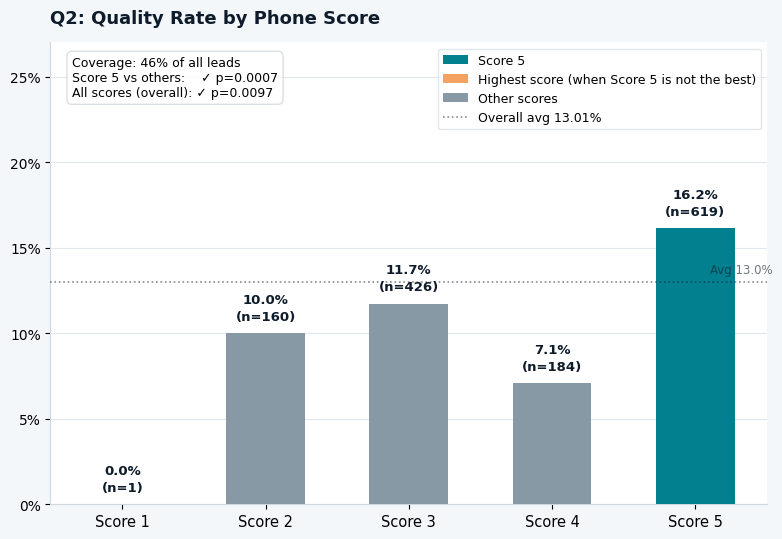

saved as phone_score_quality.png


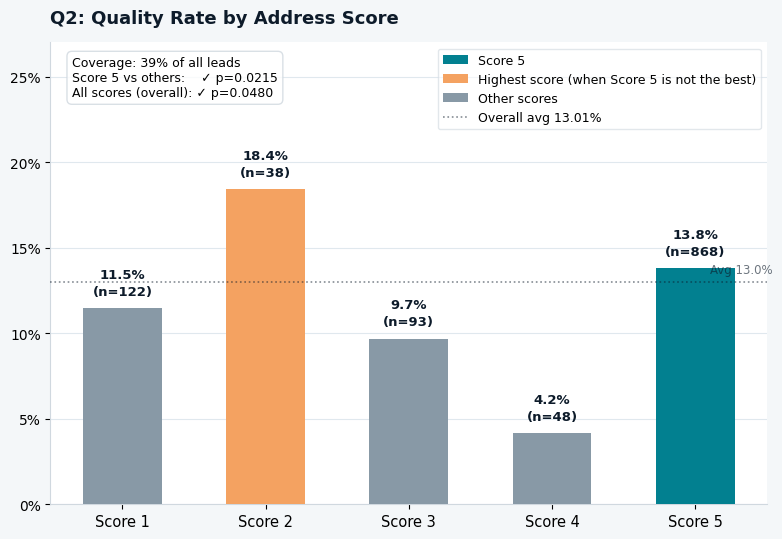

saved as address_score_quality.png


In [198]:
def plot_score(grp, score_col, coverage, chi2_5, p_5, chi2_all, p_all,
               title, filename):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    fig.patch.set_facecolor("#F4F7F9")
    ax.set_facecolor("#FFFFFF")
    x = grp[score_col].values

    best_score = grp.loc[grp["QualRate"].idxmax(), score_col]
    colors = []
    for s in x:
        if s == 5:
            colors.append("#028090")
        elif s == best_score and best_score != 5:
            colors.append("#F4A261")
        else:
            colors.append("#8899A6")

    bars = ax.bar(x, grp["QualRate"], color=colors, width=0.55, zorder=3)

    ax.axhline(y=overall, color="#0D1B2A", linewidth=1.2,
               linestyle=":", alpha=0.5, zorder=4)
    ax.text(x[-1] + 0.1, overall + 0.005,
            f"Avg {overall:.1%}", fontsize=8.5, color="#0D1B2A", alpha=0.6)

    for bar, rate, n in zip(bars, grp["QualRate"], grp["Total"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                rate + 0.006,
                f"{rate:.1%}\n(n={n})",
                ha="center", va="bottom", fontsize=9.5,
                fontweight="bold", color="#0D1B2A", linespacing=1.4)

    ax.set_xticks(x)
    ax.set_xticklabels([f"Score {s}" for s in x], fontsize=10.5)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylim(0, 0.27)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("#D0D8DF")
    ax.yaxis.grid(True, color="#E0E8EE", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

    sig_5   = "✓ p={:.4f}".format(p_5)   if p_5   < 0.05 else "✗ p={:.4f}".format(p_5)
    sig_all = "✓ p={:.4f}".format(p_all) if p_all < 0.05 else "✗ p={:.4f}".format(p_all)
    stats_text = (
        f"Coverage: {coverage:.0%} of all leads\n"
        f"Score 5 vs others:    {sig_5}\n"
        f"All scores (overall): {sig_all}"
    )
    ax.text(0.03, 0.97, stats_text,
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#D0D8DF", alpha=0.8))

    legend_elements = [
        mpatches.Patch(facecolor="#028090", label="Score 5"),
        mpatches.Patch(facecolor="#F4A261", label="Highest score (when Score 5 is not the best)"),
        mpatches.Patch(facecolor="#8899A6", label="Other scores"),
        plt.Line2D([0],[0], color="#0D1B2A", linestyle=":", alpha=0.5,
                   linewidth=1.2, label=f"Overall avg {overall:.2%}"),
    ]
    ax.legend(handles=legend_elements, fontsize=9, framealpha=0.6,
              edgecolor="#D0D8DF", loc="upper right")

    ax.set_title(title, fontsize=13, fontweight="bold",
                 color="#0D1B2A", pad=14, loc="left")

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"saved as {filename}")

plot_score(phone_grp, "PhoneScore", phone_cov,
           ph_chi2, ph_p, ph_chi2_all, ph_p_all,
           "Q2: Quality Rate by Phone Score",
           "phone_score_quality.png")

plot_score(addr_grp, "AddressScore", addr_cov,
           ad_chi2, ad_p, ad_chi2_all, ad_p_all,
           "Q2: Quality Rate by Address Score",
           "address_score_quality.png")

## Divers - phone + debt level - heat map

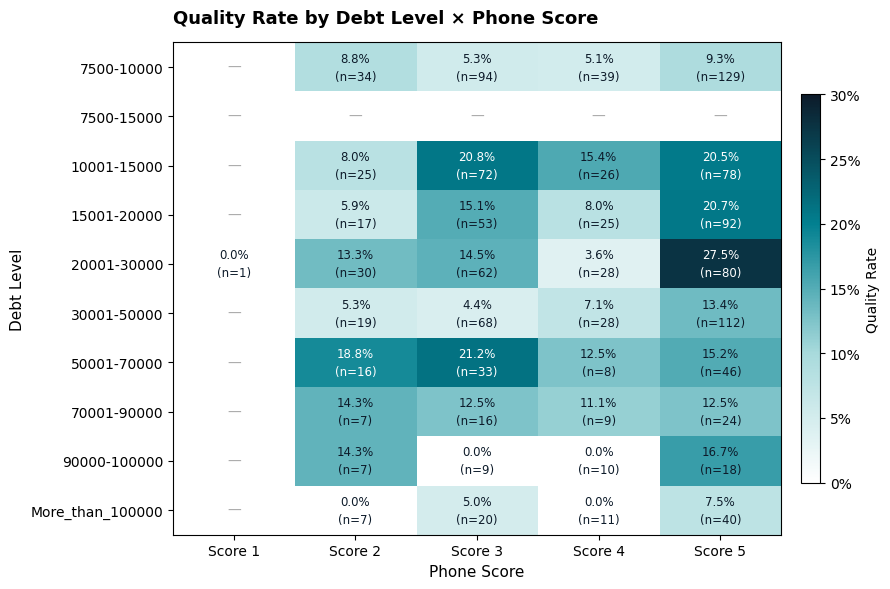

In [199]:
df_ph = df_ph.copy()
df_ph["PhoneScore"] = df_ph["PhoneScore"].astype(int)

df_ph = df_ph[df_ph["DebtLevel"].isin(debt_order)]

pivot_rate  = df_ph.pivot_table(index="DebtLevel", columns="PhoneScore",
                                 values="IsGood", aggfunc="mean").reindex(debt_order)
pivot_count = df_ph.pivot_table(index="DebtLevel", columns="PhoneScore",
                                 values="IsGood", aggfunc="count").reindex(debt_order)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = mcolors.LinearSegmentedColormap.from_list(
    "custom", ["#FFFFFF", "#A8DADC", "#028090", "#0D1B2A"]
)
im = ax.imshow(pivot_rate.values, cmap=cmap, vmin=0, vmax=0.30, aspect="auto")
for i in range(pivot_rate.shape[0]):
    for j in range(pivot_rate.shape[1]):
        val   = pivot_rate.values[i, j]
        count = pivot_count.values[i, j]
        if np.isnan(val):
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#AAAAAA")
        else:
            text_color = "white" if val > 0.18 else "#0D1B2A"
            ax.text(j, i, f"{val:.1%}\n(n={int(count)})",
                    ha="center", va="center", fontsize=8.5,
                    color=text_color, linespacing=1.5)

ax.set_xticks(range(pivot_rate.shape[1]))
ax.set_xticklabels([f"Score {c}" for c in pivot_rate.columns], fontsize=10)
ax.set_yticks(range(pivot_rate.shape[0]))
ax.set_yticklabels(pivot_rate.index, fontsize=10)
ax.set_xlabel("Phone Score", fontsize=11)
ax.set_ylabel("Debt Level", fontsize=11)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label("Quality Rate", fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Quality Rate by Debt Level × Phone Score",
             fontsize=13, fontweight="bold", pad=14, loc="left")
plt.tight_layout()
plt.savefig("heatmap_debt_phone.png", dpi=150, bbox_inches="tight")
plt.show()

## Drivers - partner/traffic source

PARTNER comparison
      Partner  Total  Good  Bad  QualRate
advertise.com      3     1    0  0.333333
  adknowledge    171    32   23  0.187135
  call_center    271    44   66  0.162362
        yahoo    955   136  147  0.142408
       google   1613   180  252  0.111593

SEARCH vs CONTENT（via ReferralDomain）
TrafficType  Total  Good  Bad  QualRate
    Content   1033   100  167  0.096805
     Search   1465   224  212  0.152901
    Unknown    515    69  109  0.133981

Chi-squared (Search vs Content): chi2=12.36, p=0.0004
Result: SIGNIFICANT

Search keywords: ['search', 'google.com', 'bing.com', 'ask.com', 'aol.com', 'yahoo.com']

Content traffic top domains:
ReferralDomain
googleads.g.doubleclick.net      290
ezinearticles.com                101
www.ehow.com                      69
www.findstuff.com                 63
www.soyouwanna.com                19
www.debtreductioninc.com          19
www.webcrawler.com                16
pagead2.googlesyndication.com     16
www.justclicklocal.com  

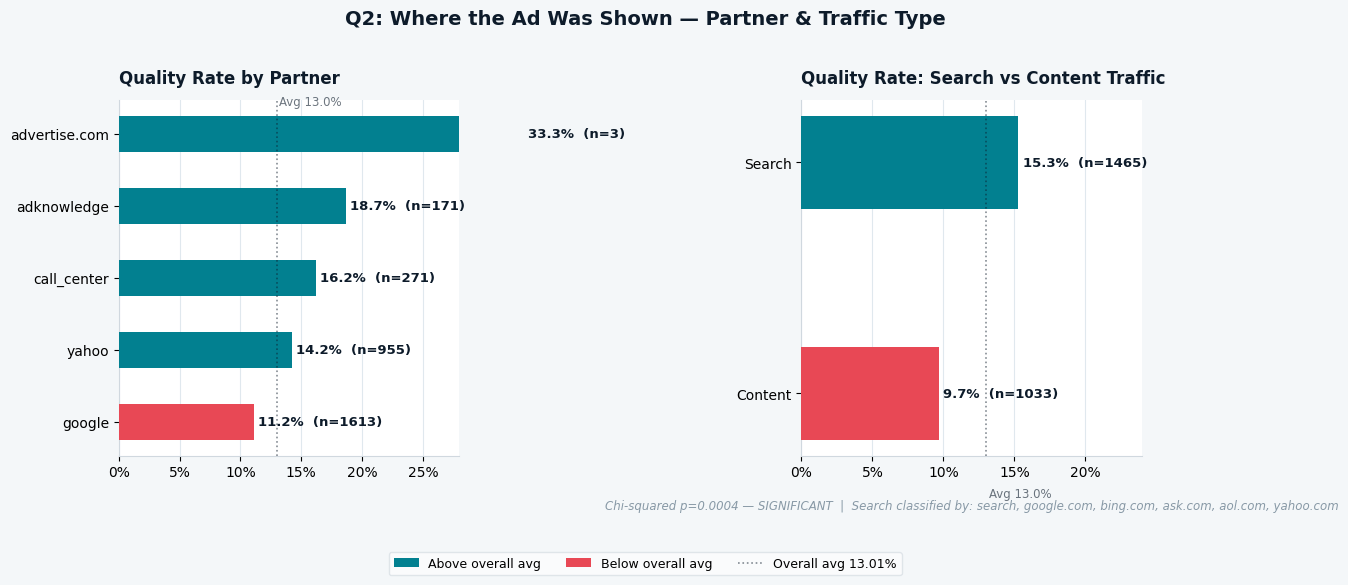

In [206]:
SEARCH_KEYWORDS = ["search", "google.com", "bing.com", "ask.com", "aol.com", "yahoo.com"]

def classify_traffic(domain):
    if pd.isna(domain):
        return "Unknown"
    domain = str(domain).lower()
    if any(kw in domain for kw in SEARCH_KEYWORDS):
        return "Search"
    return "Content"

df["TrafficType"] = df["ReferralDomain"].apply(classify_traffic)

# partner comparison
print("=" * 60)
print("PARTNER comparison")
print("=" * 60)

df["Partner"] = df["Partner"].str.lower()
partner = (
    df.groupby("Partner")
    .agg(Total=("VendorLeadID","count"), Good=("IsGood","sum"), Bad=("IsBad","sum"))
    .reset_index()
)
partner["QualRate"] = partner["Good"] / partner["Total"]
print(partner.sort_values("QualRate", ascending=False).to_string(index=False))

# Search vs Content depends on referral domain, not just widget or campaign type
print("\n" + "=" * 60)
print("SEARCH vs CONTENT（via ReferralDomain）")
print("=" * 60)
traffic = (
    df.groupby("TrafficType")
    .agg(Total=("VendorLeadID","count"), Good=("IsGood","sum"), Bad=("IsBad","sum"))
    .reset_index()
)
traffic["QualRate"] = traffic["Good"] / traffic["Total"]
print(traffic.to_string(index=False))

s = df[df["TrafficType"] == "Search"]
c = df[df["TrafficType"] == "Content"]
ct = [[s["IsGood"].sum(), s["IsBad"].sum()],
      [c["IsGood"].sum(), c["IsBad"].sum()]]
chi2, p, _, _ = chi2_contingency(ct)
print(f"\nChi-squared (Search vs Content): chi2={chi2:.2f}, p={p:.4f}")
print(f"Result: {'SIGNIFICANT' if p < 0.05 else 'NOT significant'}")

print("\nSearch keywords:", SEARCH_KEYWORDS)
print("\nContent traffic top domains:")
print(df[df["TrafficType"]=="Content"]["ReferralDomain"].value_counts().head(10).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor("#F4F7F9")

# left：Partner comparison
ax1.set_facecolor("#FFFFFF")
partner_plot = partner.sort_values("QualRate", ascending=True)
bar_colors_p = ["#028090" if r >= overall else "#E84855"
                for r in partner_plot["QualRate"]]
bars1 = ax1.barh(partner_plot["Partner"], partner_plot["QualRate"],
                 color=bar_colors_p, height=0.5, zorder=3)

ax1.axvline(x=overall, color="#0D1B2A", linewidth=1.2,
            linestyle=":", alpha=0.5, zorder=4)
ax1.text(overall + 0.002, len(partner_plot) - 0.6,
         f"Avg {overall:.1%}", fontsize=8.5, color="#0D1B2A", alpha=0.6)

for bar, rate, n in zip(bars1, partner_plot["QualRate"], partner_plot["Total"]):
    ax1.text(rate + 0.003,
             bar.get_y() + bar.get_height() / 2,
             f"{rate:.1%}  (n={n})",
             va="center", fontsize=9.5, fontweight="bold", color="#0D1B2A")

ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.set_xlim(0, 0.28)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax1.spines[spine].set_color("#D0D8DF")
ax1.xaxis.grid(True, color="#E0E8EE", linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)
ax1.tick_params(labelsize=10)
ax1.set_title("Quality Rate by Partner",
              fontsize=12, fontweight="bold", color="#0D1B2A", pad=12, loc="left")

# right：Search vs Content 
ax2.set_facecolor("#FFFFFF")
traffic_plot = traffic[traffic["TrafficType"] != "Unknown"].sort_values("QualRate", ascending=True)
bar_colors_t = ["#028090" if r >= overall else "#E84855"
                for r in traffic_plot["QualRate"]]
bars2 = ax2.barh(traffic_plot["TrafficType"], traffic_plot["QualRate"],
                 color=bar_colors_t, height=0.4, zorder=3)

ax2.axvline(x=overall, color="#0D1B2A", linewidth=1.2,
            linestyle=":", alpha=0.5, zorder=4)
ax2.text(overall + 0.002, -0.45,
         f"Avg {overall:.1%}", fontsize=8.5, color="#0D1B2A", alpha=0.6)

for bar, rate, n in zip(bars2, traffic_plot["QualRate"], traffic_plot["Total"]):
    ax2.text(rate + 0.003,
             bar.get_y() + bar.get_height() / 2,
             f"{rate:.1%}  (n={n})",
             va="center", fontsize=9.5, fontweight="bold", color="#0D1B2A")

ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.set_xlim(0, 0.24)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax2.spines[spine].set_color("#D0D8DF")
ax2.xaxis.grid(True, color="#E0E8EE", linewidth=0.8, zorder=0)
ax2.set_axisbelow(True)
ax2.tick_params(labelsize=10)
ax2.set_title("Quality Rate: Search vs Content Traffic",
              fontsize=12, fontweight="bold", color="#0D1B2A", pad=12, loc="left")

# p-value
ax2.text(0.5, -0.15,
         f"Chi-squared p={p:.4f} — SIGNIFICANT  |  "
         f"Search classified by: {', '.join(SEARCH_KEYWORDS)}",
         transform=ax2.transAxes, ha="center",
         fontsize=8.5, color="#8899A6", style="italic")

# legend
legend_elements = [
    mpatches.Patch(facecolor="#028090", label="Above overall avg"),
    mpatches.Patch(facecolor="#E84855", label="Below overall avg"),
    plt.Line2D([0],[0], color="#0D1B2A", linestyle=":", linewidth=1.2,
               alpha=0.5, label=f"Overall avg {overall:.2%}"),
]
fig.legend(handles=legend_elements, fontsize=9, framealpha=0.6,
           edgecolor="#D0D8DF", loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Q2: Where the Ad Was Shown — Partner & Traffic Type",
             fontsize=14, fontweight="bold", color="#0D1B2A", y=1.02)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("partner_traffic_analysis.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

## Drivers - State & map

In [201]:
state = df.groupby("State").agg(
    Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum")
).reset_index()
state["QualRate"] = state["Good"] / state["Total"]
print(state[state["Total"] >= 30].sort_values("QualRate", ascending=False).to_string(index=False))


State  Total  Good  Bad  QualRate
   OK     50    13    9  0.260000
   HI     32     7    6  0.218750
   MA     70    12   12  0.171429
   AL     95    16   15  0.168421
   CA    462    73   73  0.158009
   WV     52     8    7  0.153846
   OR     53     8   11  0.150943
   AZ     94    14   23  0.148936
   NV     54     8    9  0.148148
   VA    145    21   17  0.144828
   TX    323    42   43  0.130031
   FL    261    33   43  0.126437
   MI    145    17   23  0.117241
   CO    105    12   17  0.114286
   PA     75     8   11  0.106667
   AR     48     5    8  0.104167
   MO     89     9   13  0.101124
   LA     80     8   12  0.100000
   NY    283    28   50  0.098940
   IL    184    18   27  0.097826
   MD     98     8   19  0.081633
   IN     36     2    6  0.055556


In [202]:
import plotly.graph_objects as go

state["QualRatePct"] = (state["QualRate"] * 100).round(1)

state["hover"] = state.apply(
    lambda r: (
        f"<b>{r['State']}</b><br>"
        f"Quality Rate: {r['QualRate']:.1%}<br>"
        f"Total Leads: {r['Total']:,}<br>"
        f"Good: {r['Good']:,}<br>"
        f"Bad: {r['Bad']:,}<br>"
        f"vs Avg: {r['QualRate'] - overall:+.1%}"
    ), axis=1
)

state_enough = state[state["Total"] >= 30]
ct = [[r["Good"], r["Bad"]] for _, r in state_enough.iterrows()]
chi2_val, p_val, _, _ = chi2_contingency(ct)
print(f"\nChi-squared (State, n≥30): chi2={chi2_val:.2f}, p={p_val:.4f}")
print(f"Result: {'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'}")

colorscale = [
    [0.0, "#E84855"],
    [0.5, "#F4F4F4"],
    [1.0, "#028090"],
]

fig = go.Figure(go.Choropleth(
    locations=state["State"],
    z=state["QualRatePct"],
    locationmode="USA-states",
    colorscale=colorscale,
    zmin=5,
    zmax=25,
    colorbar=dict(
        title=dict(text="Quality Rate (%)", font=dict(size=12)),
        ticksuffix="%",
        thickness=15,
        len=0.6,
    ),
    text=state["hover"],
    hovertemplate="%{text}<extra></extra>",
    marker_line_color="white",
    marker_line_width=0.5,
))

fig.add_annotation(
    text=(
        f"Overall avg: {overall:.1%}  |  "
        f"Target: {target:.1%} (baseline ×1.2)  |  "
        f"Chi-squared p={p_val:.4f} ({'significant' if p_val < 0.05 else 'not significant'})"
    ),
    xref="paper", yref="paper",
    x=0.5, y=-0.05,
    showarrow=False,
    font=dict(size=11, color="#8899A6"),
    align="center"
)

fig.update_layout(
    title=dict(
        text="Q2: Lead Quality Rate by State",
        font=dict(size=18, color="#0D1B2A"),
        x=0, xanchor="left",
    ),
    geo=dict(
        scope="usa",
        projection_type="albers usa",
        showlakes=True,
        lakecolor="#C8D8E8",
        bgcolor="#F4F7F9",
        landcolor="#D0D8DF",
    ),
    paper_bgcolor="#F4F7F9",
    margin=dict(l=20, r=20, t=60, b=60),
    width=1000,
    height=620,
)

fig.write_html("state_quality_map.html")
fig.show()


Chi-squared (State, n≥30): chi2=15.92, p=0.7743
Result: NOT significant


## Drivers - Marketing Campaign

In [208]:
mcamp = df.groupby("MarketingCampaign").agg(
    Total=("VendorLeadID", "count"), Good=("IsGood", "sum"), Bad=("IsBad", "sum")
).reset_index()
mcamp["QualRate"] = mcamp["Good"] / mcamp["Total"]
print(mcamp[mcamp["Total"] >= 30].sort_values("QualRate", ascending=False).to_string(index=False))

mcamp_enough = mcamp[mcamp["Total"] >= 30]
ct = [[r["Good"], r["Bad"]] for _, r in mcamp_enough.iterrows()]
chi2_val, p_val, _, _ = chi2_contingency(ct)
print(f"\nChi-squared: chi2={chi2_val:.2f}, p={p_val:.4f}")
print(f"Result: {'SIGNIFICANT' if p_val < 0.05 else 'NOT significant'}")


 MarketingCampaign  Total  Good  Bad  QualRate
Financial Services    171    32   23  0.187135
 Debt Holding Tank    337    61   33  0.181009
       Debt Volume    143    23   18  0.160839
            Credit    100    14   15  0.140000
             state     97    12   11  0.123711
Debt Consolidation     34     4    7  0.117647
  DebtReductionInc   1468   166  227  0.113079
      Debt General    328    29   75  0.088415

Chi-squared: chi2=35.26, p=0.0000
Result: SIGNIFICANT


# opportunity analysis

In [204]:
def classify_traffic(domain):
    if pd.isna(domain): return "Unknown"
    return "Search" if any(kw in str(domain).lower() for kw in SEARCH_KEYWORDS) else "Content"
df["TrafficType"] = df["ReferralDomain"].apply(classify_traffic)

# strategy definition
LOW_HIGH_DEBT = ["7500-10000", "More_than_100000"]

target  = overall * 1.2

scenarios = {
    "Baseline\n(all leads)":
        df,
    # route 1: recommended (Search + debt filter)
    "① Exclude\nextreme debt":
        df[~df["DebtLevel"].isin(LOW_HIGH_DEBT)],
    "① + Search\ntraffic only":
        df[
            (~df["DebtLevel"].isin(LOW_HIGH_DEBT)) &
            (df["TrafficType"] == "Search")
        ],
    "① + Search\n+ Excl Head3":
        df[
            (~df["DebtLevel"].isin(LOW_HIGH_DEBT)) &
            (df["TrafficType"] == "Search") &
            (~df["WidgetName"].str.contains("Head3", na=False))
        ],
    # this is more aggressive and may loss more leads but has higher quality
    "② Phone\nScore = 5":
        df[df["PhoneScore"] == 5],

    "② Phone Score 5\n+ mid-debt":
        df[
            (df["PhoneScore"] == 5) &
            (~df["DebtLevel"].isin(["7500-10000", "7500-15000", "More_than_100000"]))
        ],
}

print(f"Baseline: {overall:.2%}  |  Target (×1.2): {target:.2%}\n")
print(f"{'Scenario':<35} {'Leads':>7} {'Lost':>7} {'QualRate':>10} {'Meets?':>8}")
print("-" * 72)
for name, subset in scenarios.items():
    label = name.replace("\n", " ")
    n     = len(subset)
    good  = subset["IsGood"].sum()
    rate  = good / n if n > 0 else 0
    lost  = len(df) - n
    flag  = "✓" if rate >= target else ""
    print(f"{label:<35} {n:>7} {lost:>7} {rate:>10.1%} {flag:>8}")

Baseline: 13.01%  |  Target (×1.2): 15.61%

Scenario                              Leads    Lost   QualRate   Meets?
------------------------------------------------------------------------
Baseline (all leads)                   3021       0      13.0%         
① Exclude extreme debt                 2388     633      14.6%         
① + Search traffic only                1186    1835      16.9%        ✓
① + Search + Excl Head3                1145    1876      17.2%        ✓
② Phone Score = 5                       619    2402      16.2%        ✓
② Phone Score 5 + mid-debt              450    2571      18.9%        ✓


## visualization of future improvements

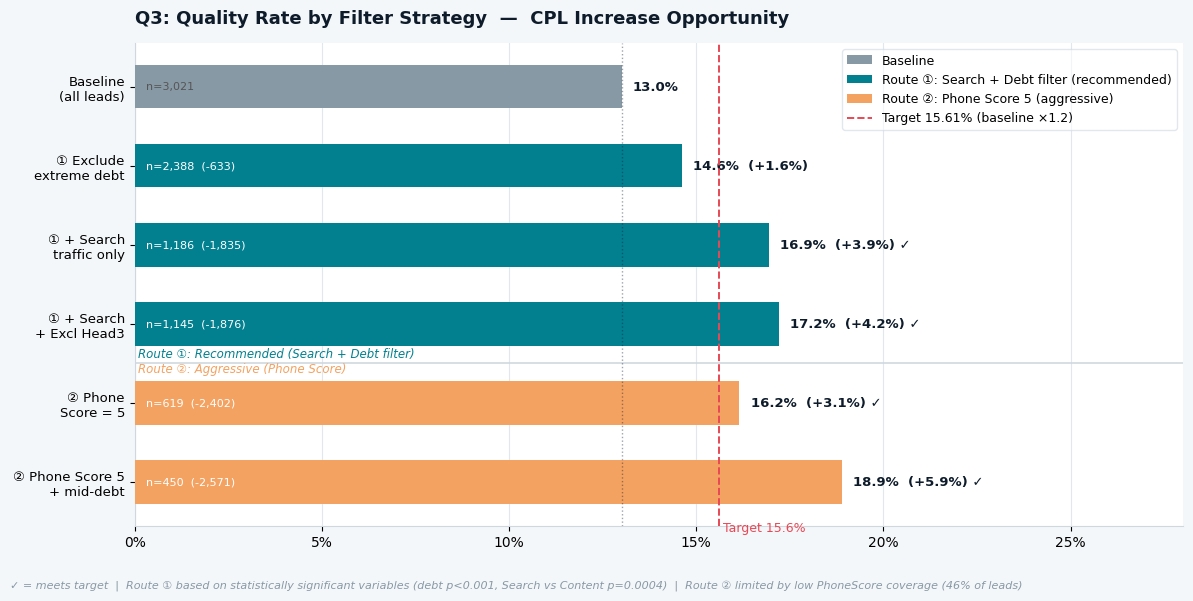

saved q3_filter_strategies.png


In [205]:
labels, rates, counts = [], [], []
for name, subset in scenarios.items():
    labels.append(name)
    n    = len(subset)
    good = subset["IsGood"].sum()
    rates.append(good / n if n > 0 else 0)
    counts.append(n)

BASELINE_RATE  = rates[0]
BASELINE_COUNT = counts[0]

# color scheme: gray for baseline, blue for route ①, orange for route ②
colors = [
    "#8899A6",   # Baseline
    "#028090",   # ① step 1
    "#028090",   # ① step 2
    "#028090",   # ① step 3
    "#F4A261",   # ② step 1
    "#F4A261",   # ② step 2
]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#F4F7F9")
ax.set_facecolor("#FFFFFF")

bars = ax.barh(labels, rates, color=colors, height=0.55, zorder=3)

# target line
ax.axvline(x=target, color="#E84855", linewidth=1.4,
           linestyle="--", zorder=4)
ax.text(target + 0.001, len(labels) - 0.5,
        f"Target {target:.1%}", color="#E84855", fontsize=9, va="top")

# baseline line
ax.axvline(x=BASELINE_RATE, color="#0D1B2A", linewidth=1.0,
           linestyle=":", alpha=0.4, zorder=4)

# two route annotations
ax.axhline(y=3.5, color="#D0D8DF", linewidth=1.2,
           linestyle="-", zorder=2)
ax.text(0.001, 3.65, "Route ②: Aggressive (Phone Score)",
        fontsize=8.5, color="#F4A261", va="bottom", style="italic")
ax.text(0.001, 3.30, "Route ①: Recommended (Search + Debt filter)",
        fontsize=8.5, color="#028090", va="top", style="italic")

# data
for i, (bar, rate, count) in enumerate(zip(bars, rates, counts)):
    delta = rate - BASELINE_RATE
    delta_str = f"  ({delta:+.1%})" if i > 0 else ""
    meets = " ✓" if rate >= target else ""
    ax.text(rate + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.1%}{delta_str}{meets}",
            va="center", fontsize=9.5, fontweight="bold", color="#0D1B2A")
    # sample size and lost leads
    lost = BASELINE_COUNT - count
    lost_str = f"n={count:,}  (-{lost:,})" if i > 0 else f"n={count:,}"
    ax.text(0.003,
            bar.get_y() + bar.get_height() / 2,
            lost_str,
            va="center", fontsize=8, color="white" if i > 0 else "#555555")

ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, 0.28)
ax.invert_yaxis()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#D0D8DF")
ax.xaxis.grid(True, color="#E0E8EE", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=9.5)
ax.tick_params(axis="x", labelsize=10)

legend_elements = [
    mpatches.Patch(facecolor="#8899A6", label="Baseline"),
    mpatches.Patch(facecolor="#028090", label="Route ①: Search + Debt filter (recommended)"),
    mpatches.Patch(facecolor="#F4A261", label="Route ②: Phone Score 5 (aggressive)"),
    plt.Line2D([0],[0], color="#E84855", linestyle="--", linewidth=1.4,
               label=f"Target {target:.2%} (baseline ×1.2)"),
]
ax.legend(handles=legend_elements, fontsize=9,
          framealpha=0.6, edgecolor="#D0D8DF", loc="upper right")

ax.set_title("Q3: Quality Rate by Filter Strategy  —  CPL Increase Opportunity",
             fontsize=13, fontweight="bold", color="#0D1B2A", pad=14, loc="left")

fig.text(0.01, 0.01,
         "✓ = meets target  |  Route ① based on statistically significant variables "
         "(debt p<0.001, Search vs Content p=0.0004)  |  "
         "Route ② limited by low PhoneScore coverage (46% of leads)",
         fontsize=8, color="#8899A6", style="italic")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("q3_filter_strategies.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("saved q3_filter_strategies.png")
